In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Preparation:

In [2]:
filepath = "C:/Users/shanm/Python_Practice/Datasets/heart_disease.xlsx"

In [3]:
description = pd.read_excel(filepath , sheet_name ="Description")
heartD = pd.read_excel(filepath , sheet_name = "Heart_disease")

In [4]:
description.shape

(12, 2)

In [5]:
heartD.shape

(908, 13)

In [6]:
heartD.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [7]:
heartD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
heartD.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


# 2. Exploratory Data Analysis (EDA):

In [9]:
heartD.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [10]:
avg_oldPeak = heartD['oldpeak'].mean()
avg_oldPeak

0.8912529550827422

In [11]:
heartD.fillna({
    'oldpeak' : avg_oldPeak
}, inplace =True)

In [12]:
heartD.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

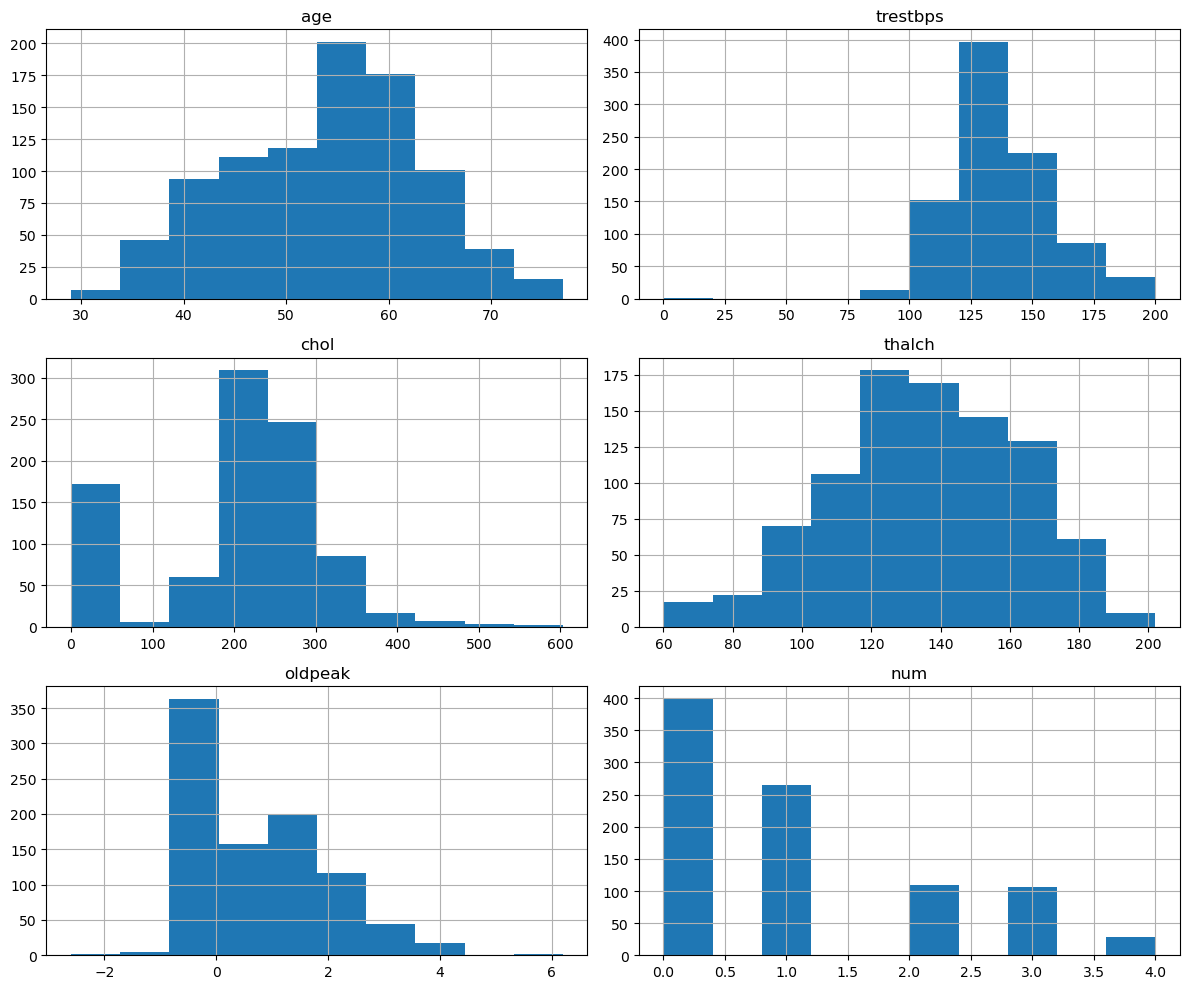

In [13]:
# Lets plot histograms to visualize data

heartD.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

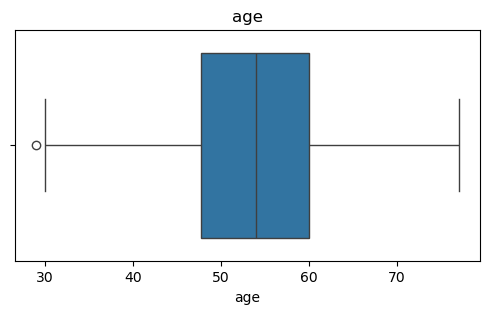

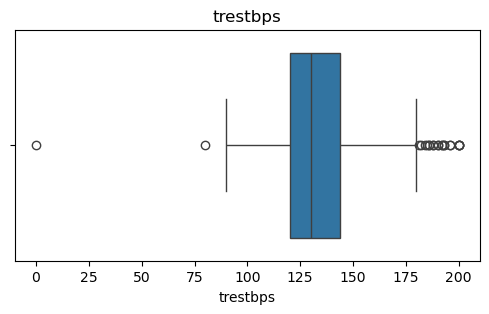

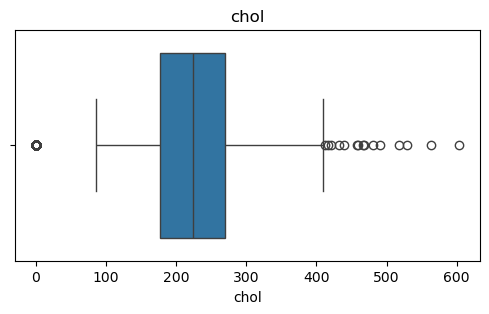

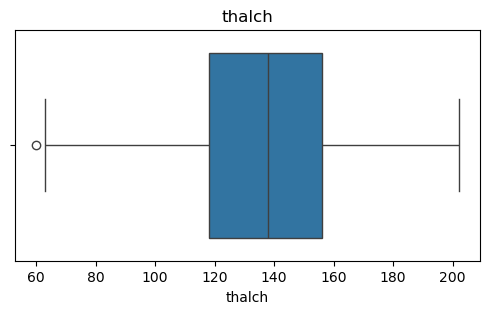

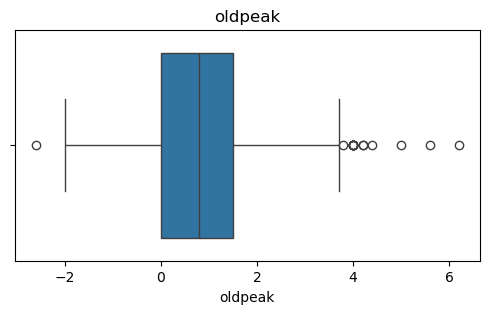

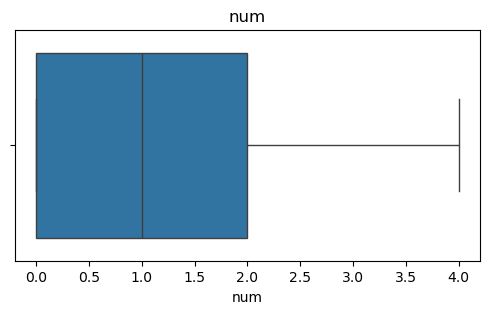

In [14]:
# lets visualize data through boxplots to detect outliers


for col in heartD.select_dtypes(include="number").columns:
    plt.figure(figsize=(6,3))
    plt.title(f"{col}")
    sns.boxplot(x=heartD[col])
    plt.show()

In [15]:
# Detecting Outliers

for col in heartD.select_dtypes(include="number").columns:
    Q1 = heartD[col].quantile(0.25)
    Q3 = heartD[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = heartD[(heartD[col] < lower) | (heartD[col] > upper)]
    print(f"{col} outliers : {len(outliers)}")


age outliers : 1
trestbps outliers : 22
chol outliers : 187
thalch outliers : 1
oldpeak outliers : 16
num outliers : 0


High variability in cholesterol

- The large number of outliers means: Cholesterol values are widely spread and right-skewed.Extreme cholesterol values likely represent high-risk individuals rather than noise.The cholesterol feature exhibited a large number of statistical outliers (187 instances), indicating a highly skewed distribution with significant variability. In the context of heart disease, elevated cholesterol levels are medically relevant and often associated with increased risk. Therefore, these outliers were not treated as noise but as meaningful observations. Since Decision Tree models are robust to outliers, no removal was performed.

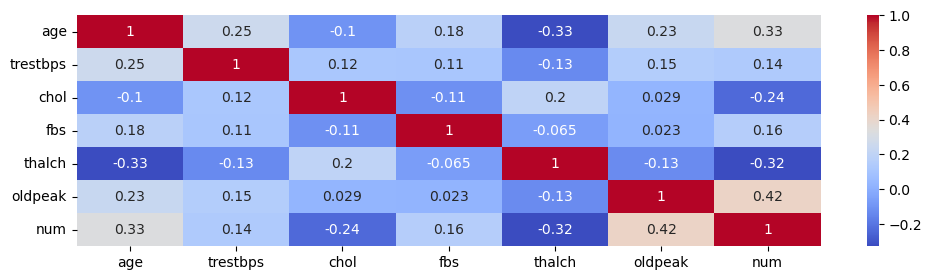

In [16]:
# Co-relation matrix

plt.figure(figsize=(12,3))
sns.heatmap(heartD.corr(numeric_only=True) , annot=True , cmap='coolwarm')
plt.show()

Observations:

- Oldpeak is strongest predictor.Higher ST depression (oldpeak) is strongly associated with heart disease.
- Age matters.Older individuals have a higher likelihood of heart disease.
- thalch (max heart rate) is negatively correlated.Lower maximum heart rate → higher chance of heart disease
- Cholesterol alone is not a strong predictor in this dataset.Even though you saw many outliers,it doesn’t strongly influence the target
- Resting blood pressure and fasting blood sugar have limited impact individually.Therefore , trestfbs,fbs are weak predictors
- age vs thalch shows a strong negative corelation .i.e.-0.33 .It states Older people has lower max heart rate
- Since most features show weak linear correlation, a non-linear model like Decision Tree is appropriate for this dataset

# 3. Feature Engineering:

In [17]:
print(heartD['fbs'].unique())
print(heartD['exang'].unique())

[ True False]
[False True 'FALSE' 'TURE']


I identified Exang has three values : TRUE , FALSE and TURE (True mistakenly written as TURE).So,lets fix this

In [18]:
heartD['fbs'] = heartD['fbs'].astype(str).map({'True': 1, 'False': 0})
heartD['exang'] = heartD['exang'].astype(str).map({'True': 1, 'False': 0, 'TURE': 1, 'FALSE':0})

In [19]:
from sklearn.preprocessing import LabelEncoder

for col in heartD.select_dtypes(include='object').columns:
    heartD = pd.get_dummies(heartD , drop_first=True)

heartD.head() 

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,1,150,0,2.3,0,True,False,False,True,False,False,False,False,False,False
1,41,135,203,0,132,0,0.0,0,True,True,False,False,True,False,True,False,False,False
2,57,140,192,0,148,0,0.4,0,True,False,False,False,True,False,True,False,False,False
3,52,118,186,0,190,0,0.0,0,True,False,False,True,False,False,True,False,False,False
4,57,110,201,0,126,1,1.5,0,True,False,False,False,True,False,True,False,False,False


In [20]:
from sklearn.preprocessing import StandardScaler
ss =StandardScaler()

for col in ['age', 'trestbps', 'chol', 'thalch','oldpeak']:
    heartD[col] = ss.fit_transform(heartD[[col]])
heartD.head(2)   

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.006027,0.567394,0.281297,1,0.524183,0,1.334996,0,True,False,False,True,False,False,False,False,False,False
1,-1.397560,0.076967,0.013526,0,-0.147705,0,-0.844594,0,True,True,False,False,True,False,True,False,False,False


# 4. Decision Tree Classification:

In [21]:
from sklearn.model_selection import train_test_split

In [56]:
X = heartD.drop('num', axis=1)
y = (heartD['num'] > 0).astype(int)
X.head(1)

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.006027,0.567394,0.281297,1,0.524183,0,1.334996,True,False,False,True,False,False,False,False,False,False


In [57]:
y.head(2)

0    0
1    0
Name: num, dtype: int32

In [58]:
X_train , X_test ,y_train, y_test = train_test_split(X,y, test_size=0.2 , random_state=42)
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((726, 17), (182, 17), (726,), (182,))

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [101]:
dtree =DecisionTreeClassifier(class_weight='balanced',criterion='entropy',random_state=42 , max_depth=3 , min_samples_split=2 )
dtree.fit(X_train , y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=3, random_state=42)

In [102]:
yhat_test = dtree.predict(X_test)

In [104]:
from sklearn.metrics import confusion_matrix , classification_report

def eval_clf_model(y,yhat):
    cm = confusion_matrix(y,yhat)
    plt.figure(figsize=(3,3))
    sns.heatmap(cm ,annot=True , cmap="mako" ,cbar=True, fmt='d')
    print(classification_report(y,yhat))

              precision    recall  f1-score   support

           0       0.71      0.83      0.77        89
           1       0.81      0.68      0.74        93

    accuracy                           0.75       182
   macro avg       0.76      0.75      0.75       182
weighted avg       0.76      0.75      0.75       182



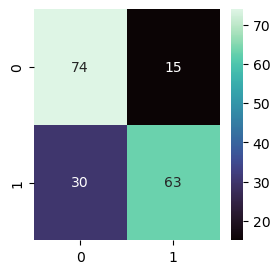

In [105]:
eval_clf_model(y_test , yhat_test)

Interpretation:
- The model is good at identifying class 0 (low false negatives), but sometimes mislabels class 1 as class 0 (false positives).
- The model is precise when it predicts class 1, but it misses quite a few actual class 1 cases (higher false negatives).


In [106]:
from sklearn.metrics import confusion_matrix, classification_report , roc_curve ,roc_auc_score, accuracy_score
def plot_auc_roc(y,yhat):
    fpr , tpr , thresh = roc_curve(y,yhat)
    auc = roc_auc_score(y,yhat)
    print(f'AUC: {auc}')
    plt.figure(figsize=(3,3))

    plt.title('AUC - ROC Curve', fontsize=15)
    plt.xlabel('False Positive Rate(FPR)')
    plt.ylabel('True Positive Rate(TPR)')

    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1] , "o--")
    plt.show()

AUC: 0.7544400144980065


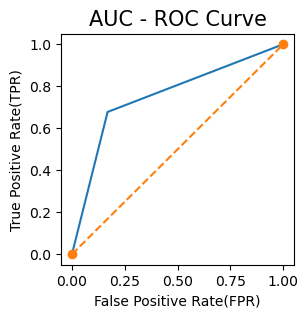

In [107]:
plot_auc_roc(y_test,yhat_test)

# 5. Hyperparameter Tuning:

In [108]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}


In [109]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.7527472527472527


# 6. Model Evaluation and Analysis:

In [110]:
features = X.columns
features

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak',
       'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_normal', 'restecg_st-t abnormality', 'slope_flat',
       'slope_upsloping', 'thal_normal', 'thal_reversable defect'],
      dtype='object')

In [111]:
cnames = heartD['num'].unique()
cnames

array([0, 1, 2, 3, 4], dtype=int64)

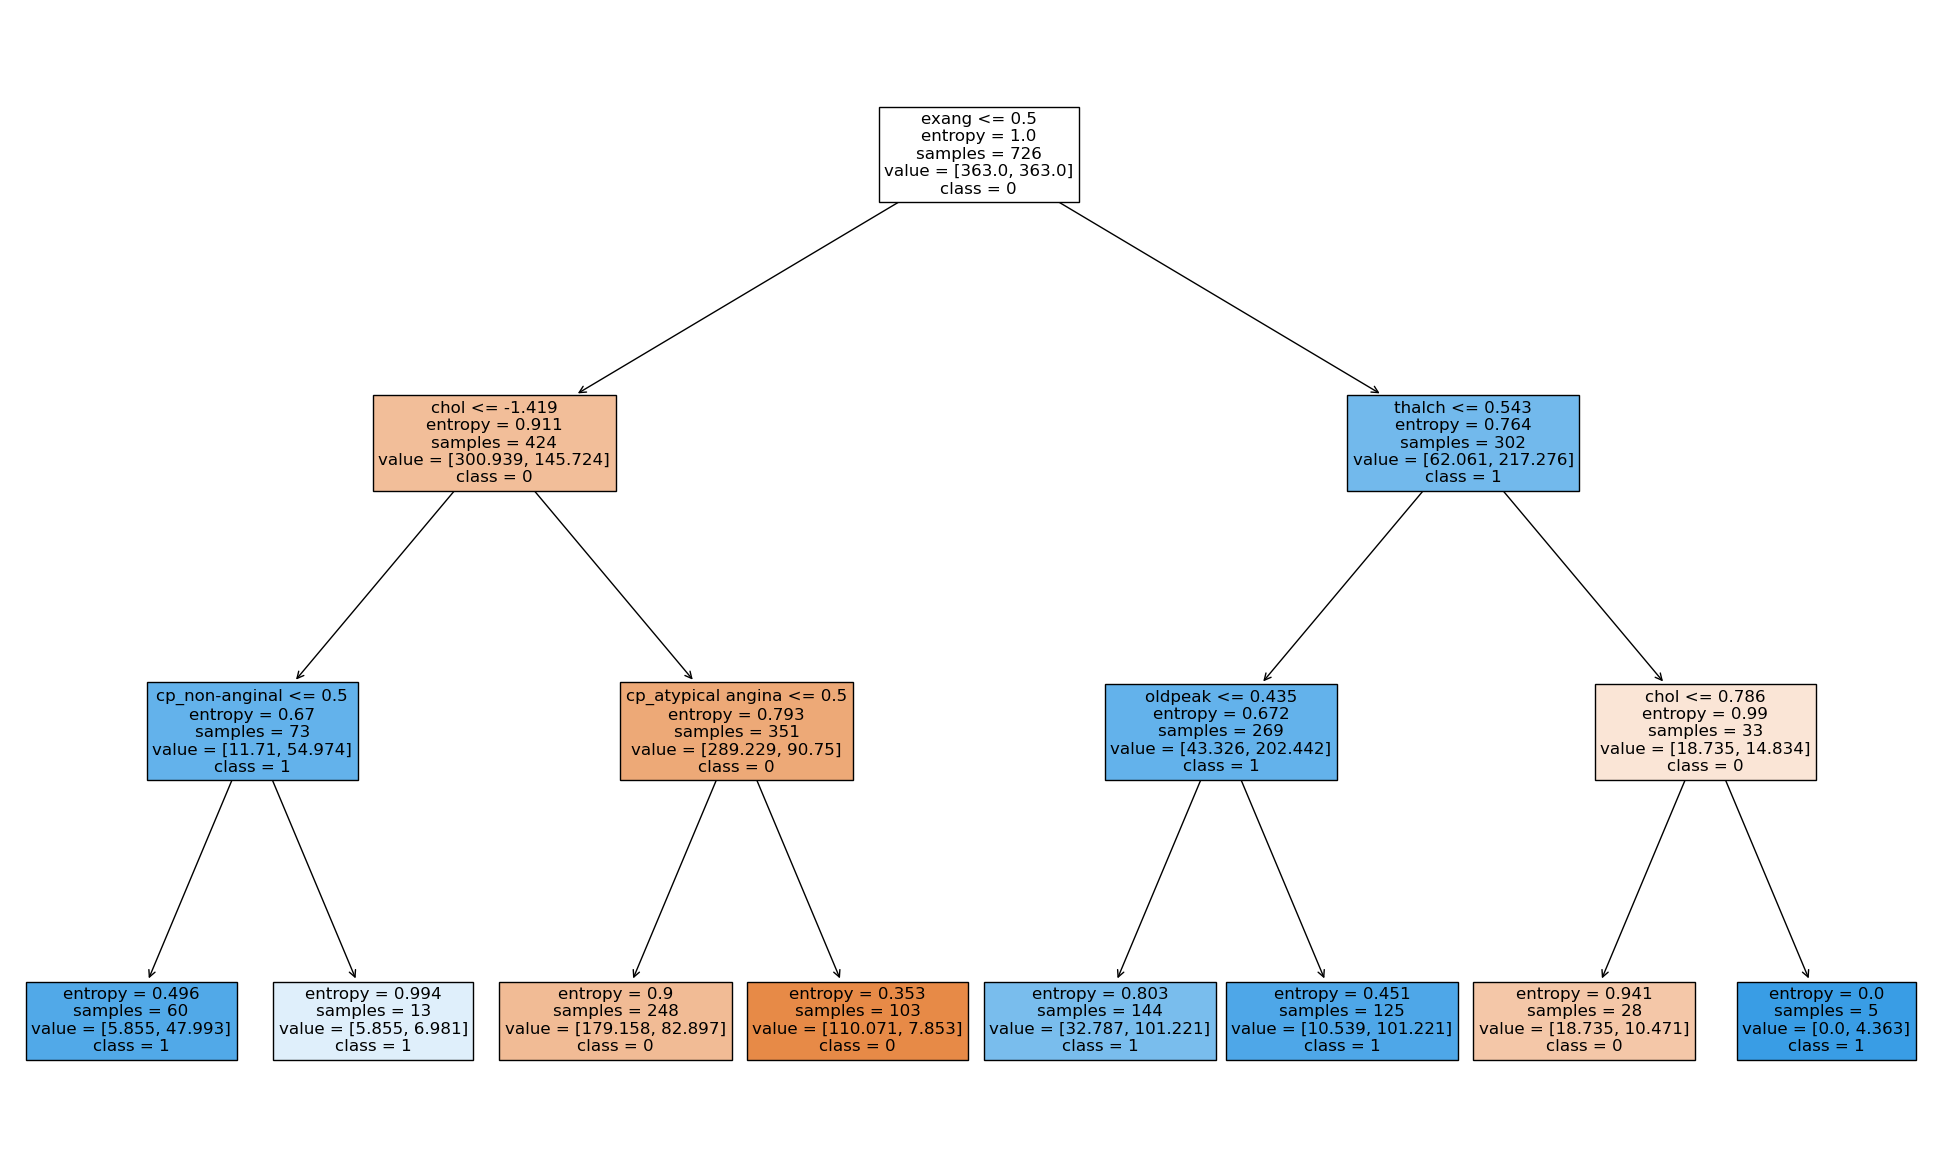

In [114]:
from sklearn.tree import plot_tree
plt.figure(figsize=(25,15))
plot_tree(dtree , feature_names=features , class_names = ['0', '1', '2', '3', '4'] , filled=True , fontsize=12)
plt.show()

Observation:

- The top node (exang <= 0.5) is the most important split — it’s the feature that best separates your data initially.
- If exang (exercise-induced angina) ≤ 0.5 ,the model predicts class 0 (no heart disease).
- If exang > 0.5 , it moves down the right branch, leaning toward class 1 (heart disease).
- This means exang is highly influential in your dataset
- Features appearing near the top (like exang, chol, thalch, oldpeak) are more influential.- 
Lower-level features (like fbs, age, trestbps) refine decisions but have less overall impact
-  Orange nodes represents class 0 (no disease).
- Blue nodesrepresentsy class 1 (disease)
- Low exang and low chol meaning likely no disease.
- High thalch and high oldpeakmeans→ likely diseas

.



# Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

Decision tree models have several hyperparameters that control how the tree is built. These directly impact overfitting, underfitting, interpretability, and accuracy.Decision trees tend to overfit by default if left unconstrained. Most hyperparameters are essentially ways to regularize the tree by limiting its growth. Here are the most important ones and how they affect performance:

1. Max Depth (max_depth)
- Limits how deep the tree can grow.

Effect:
Small depth means simpler model  may underfit
Large depth means complex model  may overfit
- One of the most important controls for balancing bias vs. variance.

2. Minimum Samples Split (min_samples_split)
- Minimum number of samples required to split a node.
Effect:
Low value means more splits  higher risk of overfitting
High value means fewer splits  may underfit
- Helps avoid learning from very small, noisy subsets.

3. Minimum Samples Leaf (min_samples_leaf)
- Minimum number of samples required in a leaf node.
Effect:
Small value means more detailed leaves  overfitting risk
Larger value means smoother predictions  better generalization
- Often improves stability more than min_samples_split.

4. Maximum Features (max_features)
- Number of features considered when looking for the best split.
Effect:
More features mean stronger splits but higher overfitting risk
Fewer features mean more randomness  better generalization (especially in ensembles)

5. Criterion (criterion)
- Measures the quality of a split.
Classification: Gini impurity, Entropy
Regression: Mean Squared Error (MSE)
Effect:
Different criteria can lead to slightly different trees.Usually small impact compared to structural hyperparameters

6. Maximum Leaf Nodes (max_leaf_nodes)
- Limits the number of leaf nodes.
Effect:
Fewer leaves mean simpler model  less overfitting
More leaves mean complex model  better fit but higher variance

2. What is the difference between the Label encoding and One-hot encoding?

Both Label Encoding and One-Hot Encoding are techniques used to convert categorical data into numerical form, but they work very differently and are suited for different situations.

Label Encoding:
- Assigns a unique integer to each category.
- Introduces an ordinal relationship (0 < 1 < 2)
- When categories have a natural order (e.g., Low < Medium < High)
- With models that can handle ordinal relationships (like tree-based models)

Drawbacks:
- Misleads models into thinking categories have ranking or distance
- Can hurt performance in models like linear regression or k-NN

One-Hot Encoding:
- Creates a new binary column for each category.
- No ordinal relationship — categories are treated as independent
- When categories are nominal (no order), e.g., colors, cities
- With most machine learning models (especially linear models)

Drawbacks:
- Increases dimensionality (can lead to curse of dimensionality)
- Inefficient for features with many unique categories